## Requirements

In [2]:
%pip install wfdb --no-deps

Note: you may need to restart the kernel to use updated packages.


## Import and Configuration

In [3]:
# Standard Library
import os
import json
import random
from pathlib import Path

# Data Manipulation & Math
import numpy as np
import pandas as pd
from tqdm import tqdm
import joblib

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Signal Processing & Domain Specific
import wfdb
from scipy.signal import butter, filtfilt, find_peaks
from scipy.stats import skew, kurtosis

# Scikit-Learn (Machine Learning)
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

# TensorFlow / Keras (Deep Learning)
import tensorflow as tf
from tensorflow.keras import mixed_precision
from tensorflow.keras import Sequential, backend as K
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, Dense, Dropout, SpatialDropout1D,
    Activation,BatchNormalization, Add, GlobalAveragePooling1D, Concatenate,
    Lambda, Reshape, UpSampling1D, Conv1DTranspose, Layer, Cropping1D
)

# Configuration & Constants
INPUT_DIR = "/kaggle/input/"
OUTPUT_DIR = "/kaggle/working/"
DATASET_PATH = os.path.join(INPUT_DIR, "datasets/khyeh0719/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1")
META_FILE_PTB = os.path.join(DATASET_PATH, "ptbxl_database.csv")
META_FILE_SCP = os.path.join(DATASET_PATH, "scp_statements.csv")

SEED = 42
SAMPLE_RATE = 500
TEST_SIZE = 0.25
MAX_RECORDS = 10000

# Set Seeds
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

2026-05-08 09:40:43.095212: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778233243.312540     758 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778233243.369009     758 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778233243.844462     758 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778233243.844504     758 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778233243.844508     758 computation_placer.cc:177] computation placer alr

## Helper Functions

In [4]:
def safe_eval_scp(scp_code):
    """
    Description: Safely converts string-formatted SCP dictionaries into Python dictionary objects.
    Input: str or dict
    Output: dict
    """
    try: return eval(scp_code) if isinstance(scp_code, str) else scp_code
    except: return {}

def ensure_len(sig, expected):
    """
    Description: Standardizes signal length by truncating or zero-padding to a fixed size.
    Note: samples = signal duration * frequency
    Input: numpy array [samples, leads] or [samples,], int
    Output: numpy array [samples, leads] or [samples,]
    """
    length = len(sig)

    # signal length is as expected
    if length == expected:
        return sig

    # signal length is more than expected
    if length > expected:
        return sig[:expected]

    # signal length is more than expected
    diff = expected - length
    if sig.ndim == 1:
        # Assume shape (time,)
        pad = np.zeros(diff)
        return np.concatenate([sig, pad])
    else: 
        # Assume shape (time, leads)
        leads = sig.shape[1]
        pad = np.zeros((diff, leads))
        return np.concatenate([sig, pad], axis=0)

def apply_bandpass_filter(sig, lowcut=0.5, highcut=45.0, fs=500.0, order=4):
    """
    Description: Applies a zero-phase Butterworth bandpass filter to ECG signals to remove 
                 low-frequency baseline wander (<0.5Hz) and high-frequency noise/powerline 
                 interference (>45Hz).
    Input: numpy array [samples, leads], float, float, float, int
    Output: numpy array [samples, leads]
    """
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    filtered_sig = filtfilt(b, a, sig, axis=0)
    return filtered_sig

def normalize_per_record(X):
    """
    Description: Performs Z-score normalization independently for each ECG record.
    Note: samples = signal duration * frequency
    Input: numpy array [ecg records, samples, leads]
    Output: numpy array [ecg records, samples, leads]
    """
    mean = np.mean(X, axis=1, keepdims=True)
    std = np.std(X, axis=1, keepdims=True) + 1e-8
    return (X - mean) / std

def print_result(res):
    """
    Description: Formats and prints classification performance metrics to the console.
    Input: dict [model, accuracy, precision, recall, f1 score]
    """
    print(f"\nModel: {res['model']}")
    print(f"Accuracy: {res['accuracy']:.2%}")
    print(f"Precision: {res['precision']:.2%}")
    print(f"Recall: {res['recall']:.2%}")
    print(f"F1 Score: {res['f1 score']:.2%}")

## Load Metadata

In [5]:
def load_metadata(max_records=MAX_RECORDS):
    """
    Description: Loads PTB-XL CSV files, applies a priority-based diagnostic hierarchy for 
                 labeling, and performs stratified sampling.
    Input: int
    Output: pandas DataFrame [ecg_id, scp_codes, label_multiclass, label_binary, filename_hr, ...]
    """
    # Load raw dataframes
    ptb_df = pd.read_csv(META_FILE_PTB)
    scp_df = pd.read_csv(META_FILE_SCP, index_col=0)

    # Convert scp_codes from string to dict
    ptb_df["scp_codes"] = ptb_df["scp_codes"].apply(safe_eval_scp)

    # Drop records without a filename
    ptb_df = ptb_df[ptb_df["filename_hr"].notna()].reset_index(drop=True)

    # Build the Dictionary Map (SCP Code -> Diagnostic Class)
    # We only keep codes that have a valid diagnostic_class (MI, STTC, CD, HYP, NORM)
    scp_df = scp_df[scp_df["diagnostic_class"].notna()]
    diagnostic_class = scp_df["diagnostic_class"].to_dict()

    # Define the Labeling Function with Hierarchy
    def get_label(scp_dict):
        """
        Description: Assigns a single diagnostic label to a record based on a 
                     priority hierarchy: MI > STTC > CD > HYP > NORM.
        Input: dict
        Output: int (-1 to 4)
        """
        # Get all diagnostic classes present for this patient
        classes = set()
        for scp_code in scp_dict.keys():
            if scp_code in diagnostic_class:
                classes.add(diagnostic_class[scp_code])

        # Check Priority: MI > STTC > CD > HYP > NORM
        if "MI" in classes: return 1      # MI
        if "STTC" in classes: return 2    # STTC
        if "CD" in classes: return 3      # CD
        if "HYP" in classes: return 4     # HYP
        if "NORM" in classes: return 0    # NORM

        return -1 # Unknown/Other (will be dropped)

    # Apply Labels
    ptb_df["label_multiclass"] = ptb_df["scp_codes"].apply(get_label)

    # Drop "Other/Unknown" (-1)
    ptb_df = ptb_df[ptb_df["label_multiclass"] != -1].reset_index(drop=True)

    # Create Binary Label: 0=NORM, 1=Abnormal (MI, STTC, CD, HYP)
    ptb_df["label_binary"] = ptb_df["label_multiclass"].apply(lambda x: 0 if x == 0 else 1)

    # Stratified Sampling (Optional)
    if max_records is not None and max_records < len(ptb_df):
        # Stratify by multiclass label to keep distribution balanced
        ptb_df, _ = train_test_split(
            ptb_df,
            train_size=max_records,
            stratify=ptb_df["label_multiclass"],
            random_state=SEED,
        )
        ptb_df = ptb_df.reset_index(drop=True)

    return ptb_df

ptb_df = load_metadata()
print("Total records used:", len(ptb_df))
print("\nMulticlass Counts (0=NORM, 1=MI, 2=STTC, 3=CD, 4=HYP):")
print(ptb_df["label_multiclass"].value_counts().sort_index())
print("\nBinary Counts (0=Normal, 1=Abnormal):")
print(ptb_df["label_binary"].value_counts())
ptb_df[["ecg_id", "scp_codes", "label_multiclass", "label_binary"]]

Total records used: 10000

Multiclass Counts (0=NORM, 1=MI, 2=STTC, 3=CD, 4=HYP):
label_multiclass
0    4239
1    2560
2    1822
3    1128
4     251
Name: count, dtype: int64

Binary Counts (0=Normal, 1=Abnormal):
label_binary
1    5761
0    4239
Name: count, dtype: int64


,ecg_id,scp_codes,label_multiclass,label_binary
0,18450,"{'IMI': 100.0, 'ABQRS': 0.0, 'SR': 0.0}",1,1
1,1421,"{'NORM': 100.0, 'NT_': 0.0, 'SR': 0.0}",0,0
2,15507,"{'NORM': 80.0, 'SARRH': 0.0}",0,0
3,17208,"{'NORM': 100.0, 'SR': 0.0}",0,0
4,9205,"{'ALMI': 100.0, 'ASMI': 100.0, 'LAFB': 100.0, ...",1,1
...,...,...,...,...
9995,2574,"{'NORM': 100.0, 'SR': 0.0}",0,0
9996,8406,"{'ASMI': 100.0, 'LVH': 100.0, 'ISC_': 100.0, '...",1,1
9997,12044,"{'LVH': 100.0, 'VCLVH': 0.0, 'STD_': 0.0, 'SR'...",4,1
9998,13097,"{'1AVB': 100.0, 'DIG': 35.0, 'NST_': 0.0, 'LPR...",2,1


## Load One Signal and Smoke Test

Showing first 1 records (12-Lead view)...


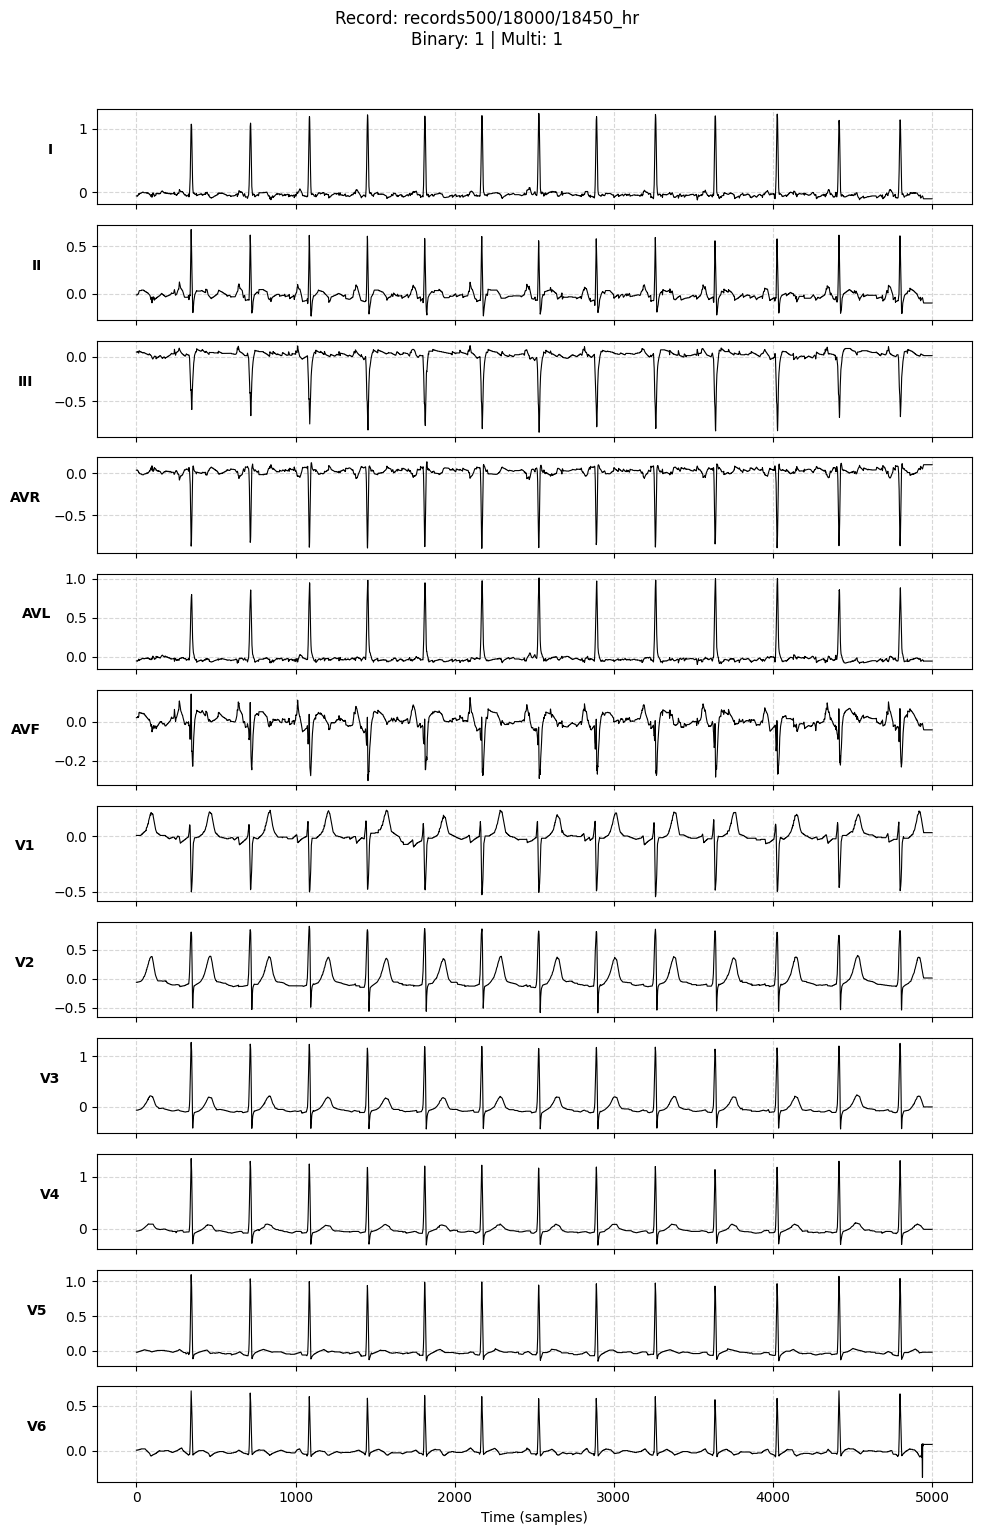

In [6]:
def load_signal_single(ecg_record):
    """
    Description: Loads a 12-lead ECG signal from the dataset using the WFDB library 
                 and converts it to float32 precision.
    Note: samples = signal duration * frequency
    Input: str
    Output: numpy array [samples, leads]
    """
    try:
        ecg_record_path = os.path.join(DATASET_PATH, ecg_record)
        signal, fields = wfdb.rdsamp(ecg_record_path)
        return signal.astype(np.float32)
    except:
        return None

def smoke_test(df, count=1):
    """
    Description: Visualizes the first N records of the provided DataFrame in a 
                 stacked 12-lead anatomical view to verify data integrity.
    Input: pandas DataFrame [filename_hr, label_binary, label_multiclass, ...], int
    """
    print(f"Showing first {count} records (12-Lead view)...")

    lead_names = ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

    for row in df.itertuples():
        sig = load_signal_single(row.filename_hr)
        if sig is None:
            continue

        # Ensure length
        sig = ensure_len(sig, SAMPLE_RATE * 10)

        # Plot all 12 leads stacked
        fig, axes = plt.subplots(12, 1, figsize=(10, 15), sharex=True)

        for i in range(12):
            ax = axes[i]
            ax.plot(sig[:, i], color='black', linewidth=0.8)
            ax.set_ylabel(lead_names[i], rotation=0, labelpad=20, fontsize=10, fontweight='bold')
            ax.grid(True, linestyle='--', alpha=0.5)
            if i < 11:
                ax.tick_params(labelbottom=False)

        plt.suptitle(f"Record: {row.filename_hr}\nBinary: {row.label_binary} | Multi: {row.label_multiclass}", y=1.02)
        plt.xlabel("Time (samples)")
        plt.tight_layout()
        plt.show()

        count -= 1
        if count == 0:
            return

smoke_test(df=ptb_df)

## Build Raw Dataset and Train Test Split

In [7]:
def build_raw_dataset(df):
    """
    Description: Iteratively loads, standardizes, and aggregates raw 12-lead ECG signals 
                 along with their binary and multiclass labels into numpy arrays.
    Note: samples = signal duration * frequency
    Input: pandas DataFrame [filename_hr, label_binary, label_multiclass]
    Output: tuple (
                numpy array [ecg records, samples, leads], 
                numpy array [ecg records], 
                numpy array [ecg records], 
                list
            )
    """
    X, y_bin, y_multi, rec_ids = [], [], [], []

    for row in tqdm(df.itertuples(), desc="Loading ECG signals"):
        # Load the full 12-lead signal
        sig = load_signal_single(row.filename_hr)
        if sig is None:
            continue
            
        # Apply Bandpass Filtering
        sig = apply_bandpass_filter(sig, fs=500.0)

        # Ensure length 
        sig = ensure_len(sig, SAMPLE_RATE * 10)

        X.append(sig)
        y_bin.append(row.label_binary)
        y_multi.append(row.label_multiclass)
        rec_ids.append(row.filename_hr)

    # Stack to create 3D Array: (ecg records, 5000, 12)
    X = np.stack(X)
    y_bin = np.array(y_bin)
    y_multi = np.array(y_multi)

    return X, y_bin, y_multi, rec_ids

# Execute the Build 
X, y_bin, y_multi, rec_ids = build_raw_dataset(ptb_df)

# Normalize
X = normalize_per_record(X)

print("\nDataset Built!")
print("X shape:", X.shape)
print("y_bin shape:", y_bin.shape)
print("y_multi shape:", y_multi.shape)


# Stratified Split (Raw Data)
X_train, X_test, y_bin_train, y_bin_test, y_multi_train, y_multi_test = train_test_split(
    X,
    y_bin,
    y_multi,
    test_size=TEST_SIZE,
    stratify=y_multi,
    random_state=SEED
)

print(f"\nSplit Sizes: Train={len(X_train)}, Test={len(X_test)}")

Loading ECG signals: 10000it [03:10, 52.54it/s]



Dataset Built!
X shape: (10000, 5000, 12)
y_bin shape: (10000,)
y_multi shape: (10000,)

Split Sizes: Train=7500, Test=2500


## Feature Extraction 

In [8]:
BEAT_WINDOW = 300
PRE_R = 100
POST_R = 200
SAFETY_MARGIN = 10

N_PCA_COMPONENTS = 5


def get_median_beats(sig):
    """
    Description: Detects R-peaks in Lead II and extracts a 300ms window around each beat, 
                 using a 'canvas' method to handle overlaps before computing a noise-resistant 
                 median beat.
    Note: samples = signal duration * frequency
    Input: numpy array [samples, leads]
    Output: numpy array [leads, beat window]
    """
    # Detect Peaks on Lead II (Index 1)
    peaks, _ = find_peaks(sig[:, 1], distance=150, height=0.1)

    # If no peaks, return zeros (12 leads x 300 samples)
    if len(peaks) == 0:
        return np.zeros((12, BEAT_WINDOW), dtype=np.float32)

    beats = []

    for i, r_curr in enumerate(peaks):
        # Define Ideal Territory
        ideal_start = r_curr - PRE_R
        ideal_end = r_curr + POST_R

        # Define Safety Limits
        if i > 0:
            limit_start = peaks[i-1] + POST_R + SAFETY_MARGIN
        else:
            limit_start = 0

        if i < len(peaks) - 1:
            limit_end = peaks[i+1] - PRE_R - SAFETY_MARGIN
        else:
            limit_end = sig.shape[0]

        # Truncate
        actual_start = max(ideal_start, limit_start)
        actual_end = min(ideal_end, limit_end)

        actual_start = max(0, actual_start)
        actual_end = min(sig.shape[0], actual_end)

        # The Canvas Method
        canvas = np.zeros((BEAT_WINDOW, 12), dtype=np.float32)
        canvas_start_idx = PRE_R - (r_curr - actual_start)

        chunk = sig[actual_start:actual_end]
        chunk_len = len(chunk)

        if chunk_len == 0 or canvas_start_idx < 0 or (canvas_start_idx + chunk_len) > BEAT_WINDOW:
            continue

        canvas[canvas_start_idx : canvas_start_idx + chunk_len] = chunk
        beats.append(canvas)

    # Compute Median
    if len(beats) == 0:
        return np.zeros((12, BEAT_WINDOW), dtype=np.float32)

    beats = np.stack(beats)                 # Shape: (beats, 300, 12)
    median_beat = np.median(beats, axis=0)  # Shape: (300, 12)
    return median_beat.T                    # Shape: (12, 300)

def train_pca_model(X):
    """
    Description: Extracts median beats from the entire training population and fits a 
                 PCA model to capture the top 5 morphological variance components across 
                 all lead waveforms.
    Input: numpy array [ecg records, samples, leads]
    Output: sklearn.decomposition.PCA object
    """
    print("Preparing data for PCA training...")
    all_beats = []

    for x in tqdm(X, desc="Extracting Training Beats"):
        mb = get_median_beats(x) # Shape: (12, 300)
        all_beats.append(mb)     # Shape: (ecg records, 12, 300)

    X_for_pca = np.vstack(all_beats) # Shape: (ecg records * 12, 300)

    print(f"Training PCA on {X_for_pca.shape[0]} individual lead waveforms...")
    pca = PCA(n_components=N_PCA_COMPONENTS)
    pca.fit(X_for_pca)

    print(f"PCA Variance Explained: {np.sum(pca.explained_variance_ratio_):.2%}")
    return pca

def extract_pca_features(X, pca_model):
    """
    Description: Transforms raw 12-lead signals into a compressed feature vector by 
                 projecting their median beats into the trained PCA space.
    Input: numpy array [ecg records, samples, leads], sklearn.decomposition.PCA object
    Output: numpy array [ecg records, features]
    """
    features = []

    for x in tqdm(X, desc="Transforming Features"):
        mb = get_median_beats(x)          # Shape: (12, 300)
        coeffs = pca_model.transform(mb)  # Shape: (12, 5)
        flatten_coeffs = coeffs.flatten() # Shape: (12 * 5)
        features.append(flatten_coeffs)   # Shape: (5000, 60)

    return np.array(features)

def show_feature_table(features, lead_idx=None):
    """
    Description: Formats the extracted PCA components into a pandas DataFrame with 
                 anatomical lead naming for inspection and display.
    Input: numpy array [ecg records, features], int or None
    """
    # Generate Column Names
    lead_names = ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
    col_names = [f"{lead}_C{i+1}" for lead in lead_names for i in range(N_PCA_COMPONENTS)]

    # Create Full DataFrame
    df = pd.DataFrame(features, columns=col_names)

    # Filter or Show All
    if lead_idx is not None:
        if 0 <= lead_idx < 12:
            target_lead = lead_names[lead_idx]
            start_col = lead_idx * N_PCA_COMPONENTS
            end_col = start_col + N_PCA_COMPONENTS

            print(f"\n--- Features for Lead {target_lead} (Index {lead_idx}) ---")
            display(df.iloc[:, start_col:end_col].head())
        else:
            print(f"Error: Lead index must be 0-11.")
    else:
        print("\n--- All 60 Features (12 Leads x 5 Components) ---")
        display(df.head())

# Train PCA (On Training Set Only)
pca = train_pca_model(X_train)

# Extract Features
print("\nExtracting features for Training Set...")
Xf_train = extract_pca_features(X_train, pca)

print("\nExtracting features for Test Set...")
Xf_test = extract_pca_features(X_test, pca)

# Scale Features
scaler = StandardScaler()
Xf_train = scaler.fit_transform(Xf_train)
Xf_test = scaler.transform(Xf_test)

# Show Features
show_feature_table(Xf_train, lead_idx=1)

Preparing data for PCA training...


Extracting Training Beats: 100%|██████████| 7500/7500 [00:09<00:00, 771.81it/s]


Training PCA on 90000 individual lead waveforms...
PCA Variance Explained: 92.33%

Extracting features for Training Set...


Transforming Features: 100%|██████████| 7500/7500 [00:12<00:00, 608.42it/s]



Extracting features for Test Set...


Transforming Features: 100%|██████████| 2500/2500 [00:04<00:00, 616.44it/s]


--- Features for Lead II (Index 1) ---


,II_C1,II_C2,II_C3,II_C4,II_C5
0,1.148905,1.025725,-0.334472,0.883100,0.336315
1,1.075626,-0.639434,-0.560135,-0.489678,-0.869328
2,1.075647,1.590929,2.072283,0.818393,-0.066801
3,0.947020,0.650832,-0.342910,0.292169,2.129843
4,1.090386,-0.312179,-1.613839,0.645821,0.578383


## Universal Evaluator

In [10]:
def evaluate_model(model_name, y_true, y_pred):
    """
    Description: Calculates key classification metrics, prints a detailed classification report, 
                 and visualizes the results via a Confusion Matrix.
    Input: str, numpy array [ecg records], numpy array [ecg records]
    Output: dict [model, accuracy, precision, recall, f1 score]
    """
    print(f"\n{'='*40}")
    print(f"EVALUATION: {model_name}")
    print(f"{'='*40}")

    # Calculate Metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    # Print Report
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print("-" * 20)
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Abnormal']))

    # Plot Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Abnormal'])

    fig, ax = plt.subplots(figsize=(5, 5))
    disp.plot(cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(f"{model_name} Confusion Matrix")
    plt.show()

    # Return Object
    return {
        "model": model_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1 score": f1
    }


## Machine Learning Models Training

In [11]:
# Train Logistic Regression Model
lr_model = LogisticRegression(max_iter=1000, random_state=SEED)
print("Training Logistic Regression on PCA Features...")
lr_model.fit(Xf_train, y_bin_train)

# Train Random Forest Model
rf_model = RandomForestClassifier(n_estimators=200, random_state=SEED)
print("Training Random Forest on PCA Features...")
rf_model.fit(Xf_train, y_bin_train)

Training Logistic Regression on PCA Features...
Training Random Forest on PCA Features...


RandomForestClassifier(n_estimators=200, random_state=42)

## Machine Learning Models Evaluation


EVALUATION: Logistic Regression (PCA)
Accuracy:  0.7748
Precision: 0.7872
Recall:    0.8347
F1 Score:  0.8102
--------------------
Classification Report:
              precision    recall  f1-score   support

      Normal       0.76      0.69      0.72      1060
    Abnormal       0.79      0.83      0.81      1440

    accuracy                           0.77      2500
   macro avg       0.77      0.76      0.77      2500
weighted avg       0.77      0.77      0.77      2500



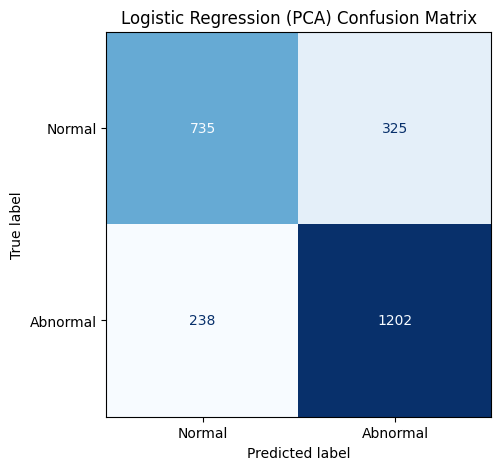


EVALUATION: Random Forest (PCA)
Accuracy:  0.7972
Precision: 0.7988
Recall:    0.8660
F1 Score:  0.8311
--------------------
Classification Report:
              precision    recall  f1-score   support

      Normal       0.79      0.70      0.75      1060
    Abnormal       0.80      0.87      0.83      1440

    accuracy                           0.80      2500
   macro avg       0.80      0.78      0.79      2500
weighted avg       0.80      0.80      0.80      2500



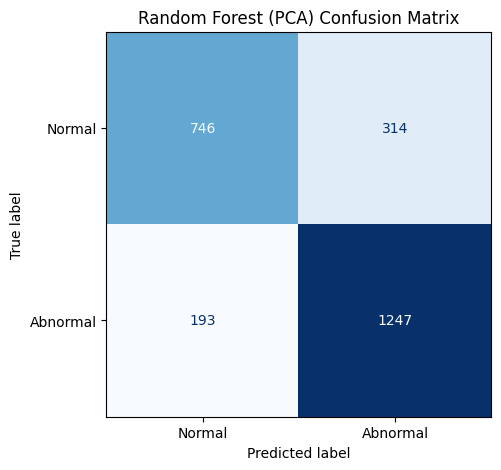

['/kaggle/working/rf_model.pkl']

In [12]:
# Train Logistic Regression Model
y_pred_lr = lr_model.predict(Xf_test)
res_lr = evaluate_model("Logistic Regression (PCA)", y_bin_test, y_pred_lr)
joblib.dump(lr_model, os.path.join(OUTPUT_DIR, 'lr_model.pkl'))

# Train Random Forest Model
y_pred_rf = rf_model.predict(Xf_test)
res_rf = evaluate_model("Random Forest (PCA)", y_bin_test, y_pred_rf)
joblib.dump(rf_model, os.path.join(OUTPUT_DIR, 'rf_model.pkl'))

## CNN Model Building and Training (Binary Classification)

In [13]:
# Configuration
INPUT_SHAPE = (5000, 12)
BATCH_SIZE = 16
EPOCHS = 50

# Define CNN Architecture
def build_cnn(input_shape=INPUT_SHAPE):
    """
    Description: Constructs a 1D Convolutional Neural Network with hierarchical feature 
                 extraction blocks (spikes to complex waves) and a Global Average Pooling head 
                 for binary classification.
    Note: samples = signal duration * frequency
    Input: tuple (samples, leads)
    Output: keras.src.models.sequential.Sequential
    """
    model = Sequential()
    model.add(Input(shape=input_shape))                              # Shape: (32, 5000, 12)

    # Block 1: The "Spike Detector" (Low-level features)
    model.add(Conv1D(filters=32, kernel_size=20, padding='same'))    # Shape: (32, 5000, 32)
    model.add(BatchNormalization())                                  # Shape: (32, 5000, 32)
    model.add(Activation('relu'))                                    # Shape: (32, 5000, 32)
    model.add(MaxPooling1D(pool_size=2))                             # Shape: (32, 2500, 32)

    # Block 2: The "Wave Detector" (Mid-level features)
    model.add(Conv1D(filters=64, kernel_size=15, padding='same'))    # Shape: (32, 2500, 64)
    model.add(BatchNormalization())                                  # Shape: (32, 2500, 64)
    model.add(Activation('relu'))                                    # Shape: (32, 2500, 64)
    model.add(MaxPooling1D(pool_size=2))                             # Shape: (32, 1250, 64)

    # Block 3: The "Complex Shape Detector" (High-level features)
    model.add(Conv1D(filters=128, kernel_size=11, padding='same'))   # Shape: (32, 1250, 128)
    model.add(BatchNormalization())                                  # Shape: (32, 1250, 128)
    model.add(Activation('relu'))                                    # Shape: (32, 1250, 128)
    model.add(MaxPooling1D(pool_size=2))                             # Shape: (32, 625, 128)

    # Block 4: Optional Deep Feature Extraction
    model.add(Conv1D(filters=256, kernel_size=7, padding='same'))   # Shape: (32, 625, 256)
    model.add(BatchNormalization())                                  # Shape: (32, 625, 256)
    model.add(Activation('relu'))                                    # Shape: (32, 625, 256)
    model.add(GlobalAveragePooling1D())                              # Shape: (32, 256)

    # Classifier Head
    model.add(Dense(128, activation='relu'))                         # Shape: (32, 128)
    model.add(Dropout(0.35))                                          # Shape: (32, 64)
    # model.add(Dense(64, activation='relu'))                          # Shape: (32, 64)
    # model.add(Dropout(0.3))                                          # Shape: (32, 45)
    
    # Binary Output
    model.add(Dense(1, activation='sigmoid'))                        # Shape: (32, 1)

    # Compile
    optimizer = Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Build
print(f"\n{'='*40}")
print("TRAINING CNN")
print(f"{'='*40}")

cnn = build_cnn()

# Train
callbacks_cnn = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001, verbose=1)
]

history_cnn = cnn.fit(
    X_train, y_bin_train,
    validation_data=(X_test, y_bin_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_cnn,
    verbose=1
)

# Save
cnn.save(os.path.join(OUTPUT_DIR, 'cnn_model.keras'))


TRAINING CNN


I0000 00:00:1778233605.271622     758 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Epoch 1/50


I0000 00:00:1778233614.945217     825 service.cc:152] XLA service 0x7db2b8001cf0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778233614.945253     825 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778233615.665742     825 cuda_dnn.cc:529] Loaded cuDNN version 91002


 13/469 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6693 - loss: 0.5989 

I0000 00:00:1778233619.719745     825 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.7923 - loss: 0.4424 - val_accuracy: 0.7708 - val_loss: 0.6365 - learning_rate: 0.0010
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.8383 - loss: 0.3729 - val_accuracy: 0.8088 - val_loss: 0.4612 - learning_rate: 0.0010
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.8482 - loss: 0.3515 - val_accuracy: 0.8192 - val_loss: 0.4303 - learning_rate: 0.0010
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.8556 - loss: 0.3315 - val_accuracy: 0.8256 - val_loss: 0.3965 - learning_rate: 0.0010
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.8668 - loss: 0.3237 - val_accuracy: 0.8184 - val_loss: 0.4390 - learning_rate: 0.0010
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.8683 - loss: 0.3139 - val_accuracy: 0.8424 - val_loss: 0.3830 - learning_rate: 0.0010
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.8708 - loss: 0.3036 - val

##  CNN Model Evaluation (Binary Classification)


CNN EVALUATION

Generating Predictions...
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step

Final Evaluation Results:

EVALUATION: CNN (Raw)
Accuracy:  0.8596
Precision: 0.8937
Recall:    0.8583
F1 Score:  0.8757
--------------------
Classification Report:
              precision    recall  f1-score   support

      Normal       0.82      0.86      0.84      1060
    Abnormal       0.89      0.86      0.88      1440

    accuracy                           0.86      2500
   macro avg       0.86      0.86      0.86      2500
weighted avg       0.86      0.86      0.86      2500



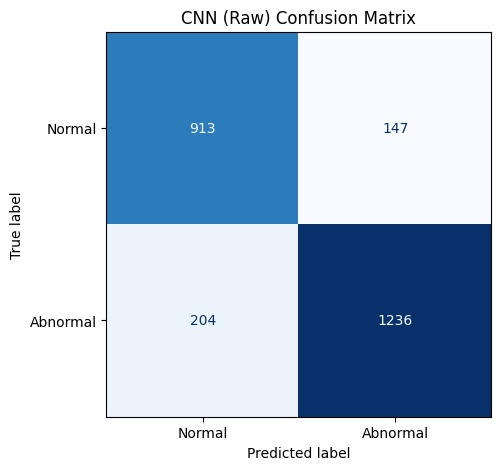

In [14]:
# Predict
print(f"\n{'='*50}")
print("CNN EVALUATION")
print(f"{'='*50}")

print("\nGenerating Predictions...")
y_pred_cnn = cnn.predict(X_test)
y_pred_cnn = (y_pred_cnn > 0.5).astype(int).flatten()

# Evaluate
print("\nFinal Evaluation Results:")
res_cnn = evaluate_model("CNN (Raw)", y_bin_test, y_pred_cnn)

## AG-ResNET Model Building and Training (Binary Classification)

In [ ]:
# Configuration
INPUT_SHAPE = (5000, 12)
NUM_CLASSES = 1
POOL_SIZE = 2
NUM_BLOCKS = 4
FILTERS_START = 64

LEARNING_RATE = 0.0005 
BATCH_SIZE = 16
EPOCHS = 50

# Define Residual Block Architecture
def residual_block(x, filters, kernel_size=7, stride=1):
    """
    Description: Implements a standard 1D Residual bottleneck with 'swish' activation and 
                 spatial dropout; includes a 1x1 convolution shortcut if dimensions change.
    Input: tensorflow.Tensor [time, channels], int, int, int
    Output: tensorflow.Tensor [time/stride, filters]
    """

    shortcut = x

    # Path A
    x = Conv1D(filters, kernel_size, strides=stride, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('swish')(x)
    x = SpatialDropout1D(0.2)(x)

    x = Conv1D(filters, kernel_size, strides=1, padding='same')(x)
    x = BatchNormalization()(x)

    # Path B
    if x.shape[-1] != shortcut.shape[-1] or stride != 1:
        shortcut = Conv1D(filters, 1, strides=stride, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = Activation('swish')(x)
    return x

# Define AG ResNet Architecture
def build_ag_resnet(input_shape=INPUT_SHAPE):
    """
    Description: Constructs the Anatomically Grouped ResNet by splitting 12 leads into 
                 5 regional branches (Septal, Anterior, Lateral, Inferior, Posterior) before 
                 fusing them for classification.
    Note: samples = signal duration * frequency
    Input: tuple (samples, leads)
    Output: keras.src.models.model.Model
    """
    # --- BLOCK 1: INPUT & TRIAGE ---
    input_layer = Input(shape=input_shape, name="ecg_input") # Shape: (16, 5000, 12)
 
    septal = Lambda(lambda x: __import__('tensorflow').gather(x, [6, 7], axis=2), name="Septal")(input_layer)            # Shape: (16, 5000, 2)
    anterior = Lambda(lambda x: __import__('tensorflow').gather(x, [8, 9], axis=2), name="Anterior")(input_layer)        # Shape: (16, 5000, 2)
    lateral = Lambda(lambda x: __import__('tensorflow').gather(x, [0, 4, 10, 11], axis=2), name="Lateral")(input_layer)  # Shape: (16, 5000, 4)
    inferior = Lambda(lambda x: __import__('tensorflow').gather(x, [1, 2, 5], axis=2), name="Inferior")(input_layer)     # Shape: (16, 5000, 3)
    posterior = Lambda(lambda x: __import__('tensorflow').gather(x, [3], axis=2), name="Posterior")(input_layer)         # Shape: (16, 5000, 1)

    # --- BLOCK 2: ENCODER ---
    branches = []
    for region_name, branch_in in zip(["Sept", "Ant", "Lat", "Inf", "Post"],
                                      [septal, anterior, lateral, inferior, posterior]):

        # Initial Feature Extraction
        x = Conv1D(FILTERS_START, 7, strides=POOL_SIZE, padding='same', name=f"{region_name}_Conv1")(branch_in) # Shape: (16, 2500, 64)
        x = BatchNormalization()(x)                                                                             # Shape: (16, 2500, 64)
        x = Activation('swish')(x)                                                                              # Shape: (16, 2500, 64)

        # Dynamic Residual Stacking
        current_filters = FILTERS_START * 2
        for i in range(NUM_BLOCKS):
            x = residual_block(x, current_filters, stride=POOL_SIZE) # Shape: (16, 1250, 128) -> (16, 625, 256) -> (16, 313, 512) -> (16, 157, 1024)
            current_filters *= 2

        x = GlobalAveragePooling1D(name=f"{region_name}_GlobalPool")(x) # Shape: (16, 1024)
        branches.append(x)                                              # Shape: (16, 5, 1024)

    # --- BLOCK 3: FUSION ---
    merged = Concatenate(name="Anatomical_Fusion")(branches) # Shape: (16, 5 * 1024)

    # --- BLOCK 4: CLASSIFICATION HEAD ---
    c = BatchNormalization()(merged)                         # Shape: (16, 5120)
    c = Dense(128, activation='swish')(c)                    # Shape: (16, 128)
    c = Dropout(0.3)(c)                                      # Shape: (16, 89)
    
    classification_output = Dense(NUM_CLASSES, activation='sigmoid', name="classification")(c)  # Shape: (16, 1)

    # --- BLOCK 5: COMPILATION (Pure Classification) ---
    model = Model(inputs=input_layer, outputs=classification_output, name="AG_ResNet")

    # Added clipnorm=1.0 to prevent gradient explosions
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE, clipnorm=1.0), 
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

# Build
print(f"{'='*50}")
print(f"AG-ResNet TRAINING (PURE CLASSIFIER)")
print(f"Input: {INPUT_SHAPE}")
print(f"Structure: {NUM_BLOCKS} Blocks | Start Filters: {FILTERS_START}")
print(f"{'='*50}")

ag_resnet = build_ag_resnet()

# Train
callbacks_ag_resnet = [
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.2, 
        patience=5, min_lr=1e-5, verbose=1
    ),
    EarlyStopping(
        monitor='val_loss', patience=12, 
        restore_best_weights=True, verbose=1
    ),
    ModelCheckpoint(
        os.path.join(OUTPUT_DIR, "ag_resnet_model.keras"),
        monitor='val_accuracy', save_best_only=True, verbose=1)
]


weight_healthy = 1.0
weight_sick = 3.0

print("\nStarting Training...")
history_ag_resnet = ag_resnet.fit(
    x=X_train,
    y=y_bin_train,
    validation_data=(X_test, y_bin_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_ag_resnet,
    class_weight={0: weight_healthy, 1: weight_sick},
    verbose=1
)

## AG-ResNET Model Evaluation (Binary Classification)

In [ ]:
# Predict
print(f"\n{'='*50}")
print("AG-ResNet EVALUATION")
print(f"{'='*50}")

print("\nGenerating Predictions...")
y_pred_ag_resnet = ag_resnet.predict(X_test).flatten()
y_pred_ag_resnet = (y_pred_ag_resnet > 0.5).astype(int)

# Evaluate
print("\nFinal Evaluation Results:")
res_ag_resnet = evaluate_model("AG-ResNet (RAW)", y_bin_test, y_pred_ag_resnet)

## Final Result Of All Models

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Lambda

print(f"{'='*50}")
print("FINAL PIPELINE: LOADING MODELS & PREDICTING")
print(f"{'='*50}\n")

# Load All Models
print("Loading All Models...")
lr_loaded = joblib.load(os.path.join(OUTPUT_DIR, 'lr_model.pkl'))
rf_loaded = joblib.load(os.path.join(OUTPUT_DIR, 'rf_model.pkl'))

cnn_loaded = load_model(os.path.join(OUTPUT_DIR, 'cnn_model.keras'))
ag_resnet_loaded = load_model(os.path.join(OUTPUT_DIR, 'ag_resnet_model.keras'), safe_mode=False)

print("All models loaded successfully!\n")

# Generate Predictions on Test Data
y_pred_lr = lr_loaded.predict(Xf_test)
y_pred_rf = rf_loaded.predict(Xf_test)

y_pred_cnn = cnn_loaded.predict(X_test, verbose=0)
y_pred_cnn = (y_pred_cnn > 0.5).astype(int).flatten()

y_pred_ag_resnet = ag_resnet_loaded.predict(X_test, verbose=0)
y_pred_ag_resnet = (y_pred_ag_resnet > 0.5).astype(int).flatten()

# 4. Final Evaluation
print("\n--- Final Test Set Evaluations ---")
final_lr = evaluate_model("Loaded Logistic Regression", y_bin_test, y_pred_lr)
final_rf = evaluate_model("Loaded Random Forest", y_bin_test, y_pred_rf)

final_cnn = evaluate_model("Loaded CNN", y_bin_test, y_pred_cnn)
final_ag_resnet = evaluate_model("Loaded AG-ResNET", y_bin_test, y_pred_ag_resnet)

final_results_df = pd.DataFrame([final_lr, final_rf, final_cnn, final_ag_resnet])
display(final_results_df.style.format({
    'accuracy': '{:.2%}',
    'precision': '{:.2%}',
    'recall': '{:.2%}',
    'f1 score': '{:.2%}'
}))